In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [24]:
iris = load_iris()
X, y = iris.data, iris.target
class_names = list(iris.target_names)

# Split data (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y
)

scaler = StandardScaler() # Scale features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

iris = load_and_explore()
class_names = list(iris.target_names)
X_train, X_test, y_train, y_test = split_data(iris.data, iris.target)
X_train_scaled, X_test_scaled = scale_features(X_train, X_test)

print(f"Dataset loaded. Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")


[DATASET] Samples   : 150
[DATASET] Features  : 4
[DATASET] Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

[SPLIT] Training samples : 120
[SPLIT] Testing samples  : 30

[SCALING] Raw data normalized (Mean ≈ 0, Variance = 1).
Dataset loaded. Train shape: (120, 4), Test shape: (30, 4)


Optimal K: 1


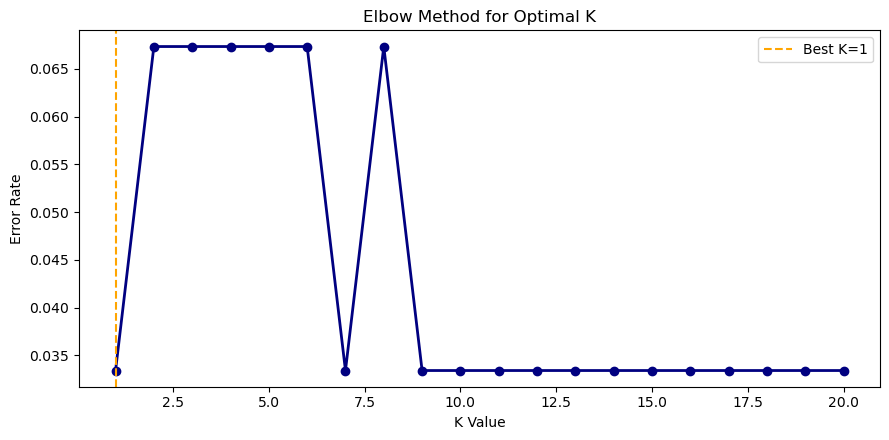

In [25]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    error_rates.append(1 - f1_score(y_test, preds, average="weighted"))

optimal_k = error_rates.index(min(error_rates)) + 1
print(f"Optimal K: {optimal_k}")

# Plot elbow curve
plt.figure(figsize=(9, 4.5))
plt.plot(k_range, error_rates, marker="o", color="navy", linewidth=2)
plt.axvline(x=optimal_k, color="orange", linestyle="--", label=f"Best K={optimal_k}")
plt.title("Elbow Method for Optimal K")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.legend()
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



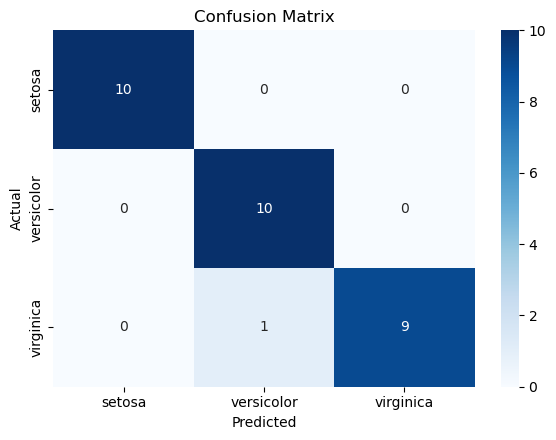

In [26]:
# Train model with optimal K
model = KNeighborsClassifier(n_neighbors=optimal_k)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)

# Metrics
print("Classification Report:")
print(classification_report(y_test, predictions, target_names=class_names))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()